In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# 1. Generate Synthetic Data
np.random.seed(42)
num_samples = 100
X = np.linspace(-3, 3, num_samples).reshape(-1, 1)
y = 2 * X**3 - 5 * X**2 + 3 * X + 5 + np.random.normal(0, 5, num_samples).reshape(-1, 1)

# Split data into training and validation sets
# Simple split for demonstration purposes
train_size = int(0.7 * num_samples)
X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size:], y[train_size:]

print(f"Training data shape: {X_train.shape}, {y_train.shape}")
print(f"Validation data shape: {X_val.shape}, {y_val.shape}")

Training data shape: (70, 1), (70, 1)
Validation data shape: (30, 1), (30, 1)


In [ ]:
# 2. Build a neural network designed to overfit
model_overfit = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(1,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

model_overfit.compile(optimizer='adam', loss='mse')
model_overfit.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,297 (122.25 KB)

 Trainable params: 31,297 (122.25 KB)

 Non-trainable params: 0 (0.00 B)

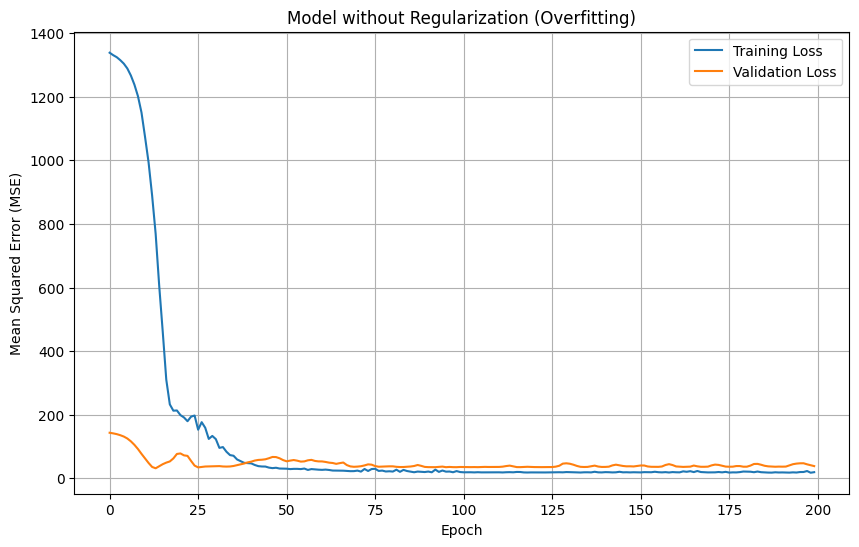


Training MSE (without regularization): 18.05
Validation MSE (without regularization): 38.54


In [ ]:
# 3. Train the network and observe overfitting
history_overfit = model_overfit.fit(X_train, y_train, epochs=200, verbose=0, validation_data=(X_val, y_val))

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history_overfit.history['loss'], label='Training Loss')
plt.plot(history_overfit.history['val_loss'], label='Validation Loss')
plt.title('Model without Regularization (Overfitting)')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

train_mse_overfit = model_overfit.evaluate(X_train, y_train, verbose=0)
val_mse_overfit = model_overfit.evaluate(X_val, y_val, verbose=0)
print(f"\nTraining MSE (without regularization): {train_mse_overfit:.2f}")
print(f"Validation MSE (without regularization): {val_mse_overfit:.2f}")

In [ ]:
# 4. Introduce Dropout as a regularization technique
model_regularized = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape=(1,)),
    layers.Dropout(0.3), # Dropout layer
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3), # Dropout layer
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2), # Dropout layer
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2), # Dropout layer
    layers.Dense(32, activation='relu'),
    layers.Dense(1)
])

model_regularized.compile(optimizer='adam', loss='mse')
model_regularized.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,297 (122.25 KB)

 Trainable params: 31,297 (122.25 KB)

 Non-trainable params: 0 (0.00 B)

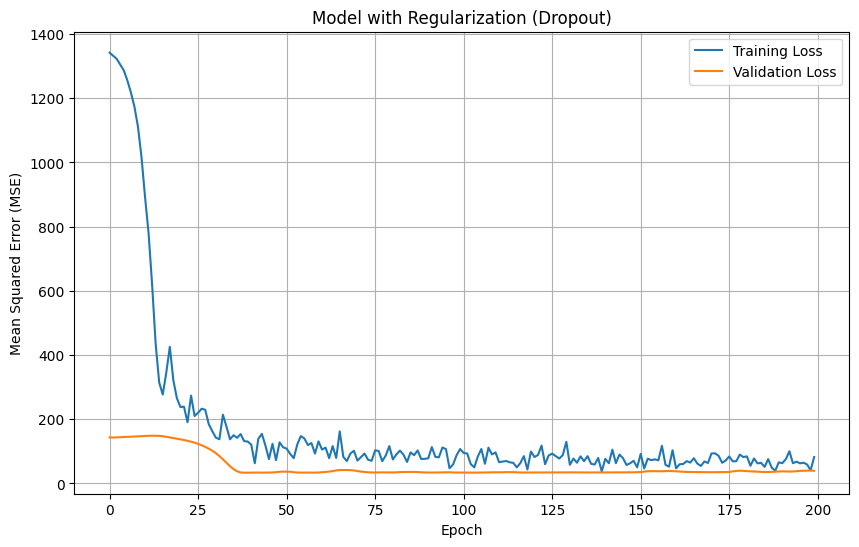


Training MSE (with regularization): 22.41
Validation MSE (with regularization): 39.39


In [ ]:

history_regularized = model_regularized.fit(X_train, y_train, epochs=200, verbose=0, validation_data=(X_val, y_val))

# Plot training and validation loss
plt.figure(figsize=(10, 6))
plt.plot(history_regularized.history['loss'], label='Training Loss')
plt.plot(history_regularized.history['val_loss'], label='Validation Loss')
plt.title('Model with Regularization (Dropout)')
plt.xlabel('Epoch')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)
plt.show()

train_mse_regularized = model_regularized.evaluate(X_train, y_train, verbose=0)
val_mse_regularized = model_regularized.evaluate(X_val, y_val, verbose=0)
print(f"\nTraining MSE (with regularization): {train_mse_regularized:.2f}")
print(f"Validation MSE (with regularization): {val_mse_regularized:.2f}")